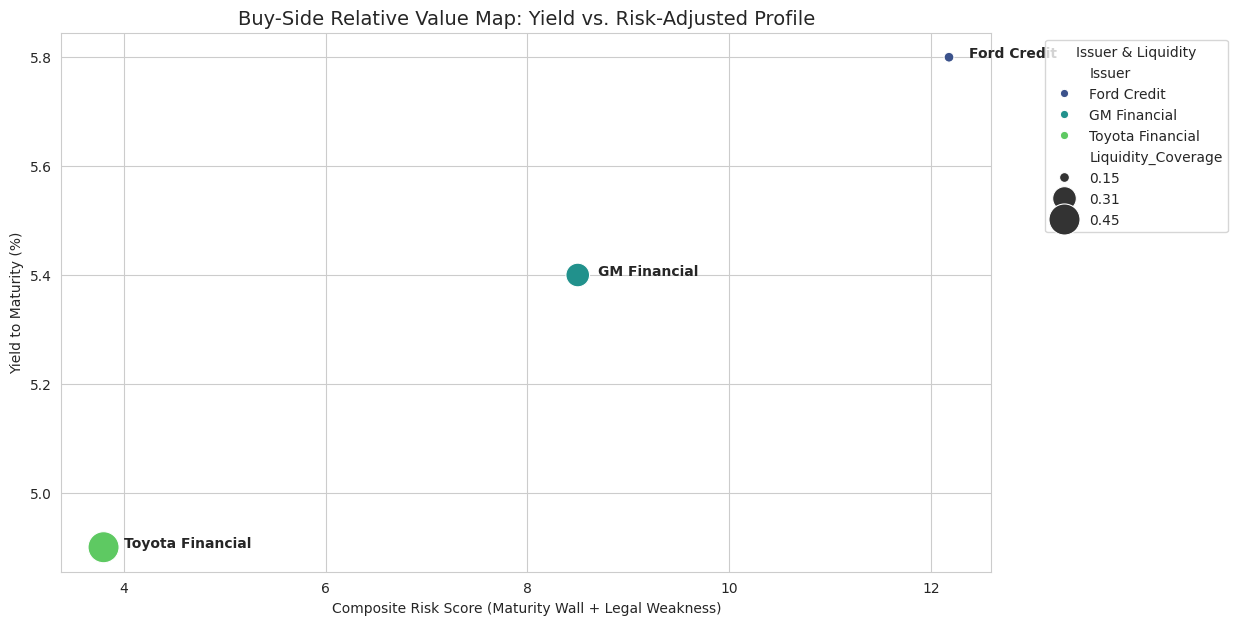

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create the Dataset (The Relative Value Universe)
data = {
    'Issuer': ['Ford Credit', 'GM Financial', 'Toyota Financial'],
    'Yield_to_Maturity': [5.8, 5.4, 4.9],
    'Covenant_Score': [3, 5, 8],
    'Maturity_Wall_2026_BN': [51.8, 35.0, 18.0],
    'Liquidity_Coverage': [0.15, 0.31, 0.45]
}

df = pd.DataFrame(data)

# 2. Feature Engineering: Calculate a Composite Risk Score
# We normalize the Maturity Wall and invert the Covenant Score
# (since 10 is high protection/low risk)
df['Risk_Score'] = (df['Maturity_Wall_2026_BN'] / 10) + (10 - df['Covenant_Score'])

# 3. Create the Relative Value Visualization
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# X = Risk, Y = Reward (Yield).
# Point size represents Liquidity Coverage (Cash buffer).
scatter = sns.scatterplot(
    data=df,
    x='Risk_Score',
    y='Yield_to_Maturity',
    hue='Issuer',
    size='Liquidity_Coverage',
    sizes=(50, 500), # FIX: Reduced range for better scale
    palette='viridis'
)

# FIX: Move legend outside the plot area to prevent overlapping
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Issuer & Liquidity')

# Add labels to the points with a slight offset (+0.2)
for i in range(df.shape[0]):
    plt.text(df.Risk_Score[i] + 0.2, df.Yield_to_Maturity[i], df.Issuer[i],
             fontsize=10, weight='bold')

plt.title('Buy-Side Relative Value Map: Yield vs. Risk-Adjusted Profile', fontsize=14)
plt.xlabel('Composite Risk Score (Maturity Wall + Legal Weakness)')
plt.ylabel('Yield to Maturity (%)')

# Save for GitHub /outputs folder
plt.savefig('auto_captive_rv_map_fixed.png', bbox_inches='tight')